In [2]:
from sklearn.datasets import make_regression
import numpy as np

In [15]:
X,y = make_regression(n_samples=8, n_features=1, n_informative=1, n_targets=1,noise=80,random_state=13)


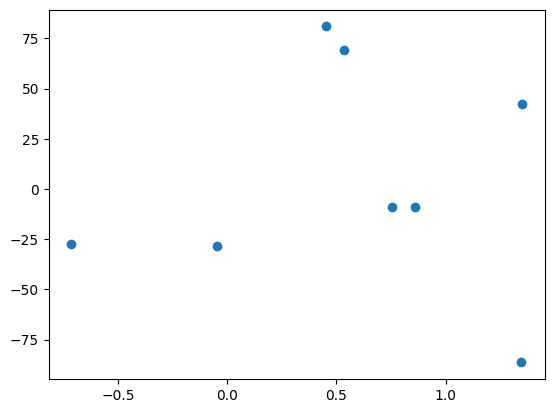

In [16]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [17]:
from sklearn.linear_model import LinearRegression
df = LinearRegression()
df.fit(X,y)


LinearRegression()

In [18]:
df.coef_


array([0.73380019])

In [19]:
df.intercept_

np.float64(3.5924335101066527)

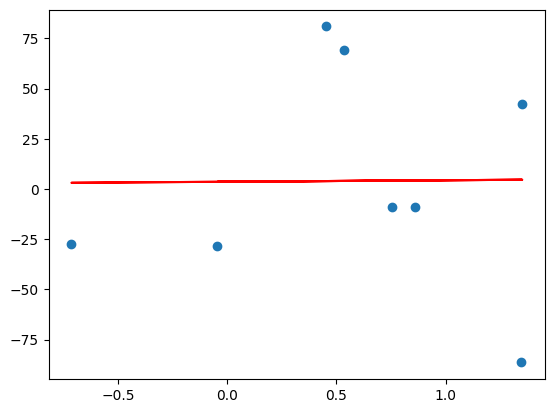

In [20]:
plt.scatter(X,y)
plt.plot(X,df.predict(X),color='red')

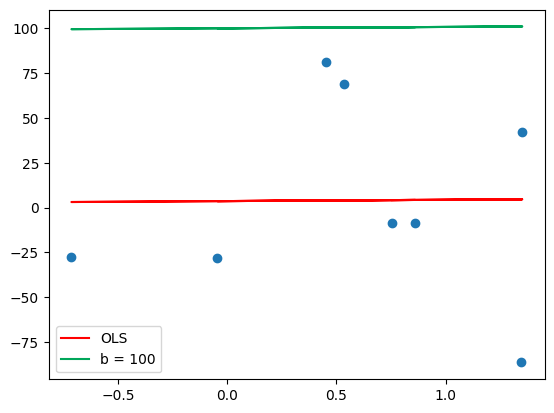

In [37]:
y_pred = ((0.73 * X) + 100).reshape(-1)
plt.scatter(X,y)
plt.plot(X,df.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#00a65a',label='b = 100')
plt.legend()
plt.show()

In [38]:
m = 0.73
b = 100
loss_slope = -2 * np.sum((y - m*X.ravel()-b))
loss_slope

np.float64(1542.486576953277)

In [39]:
lr = 0.1

step_size = loss_slope*lr
step_size


np.float64(154.24865769532772)

In [40]:
b = b - step_size
b

np.float64(-54.24865769532772)

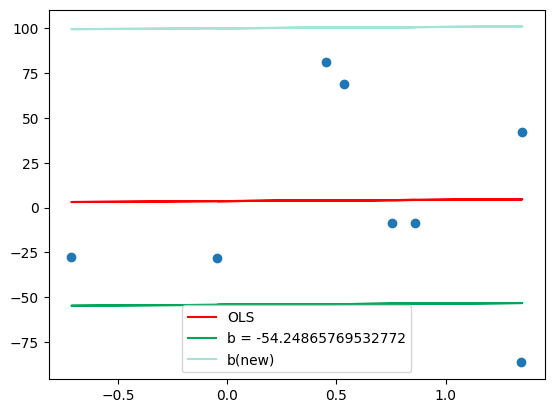

In [41]:
y_pred1 = ((0.73 * X) + b).reshape(-1)

plt.scatter(X,y)
plt.plot(X,df.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b(new)')
plt.legend()
plt.show()

In [42]:
loss_slope = -2*np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(-925.4919461719663)

In [43]:
step_size = loss_slope * lr
step_size

np.float64(-92.54919461719663)

In [44]:
b = b - step_size
b

np.float64(38.30053692186891)

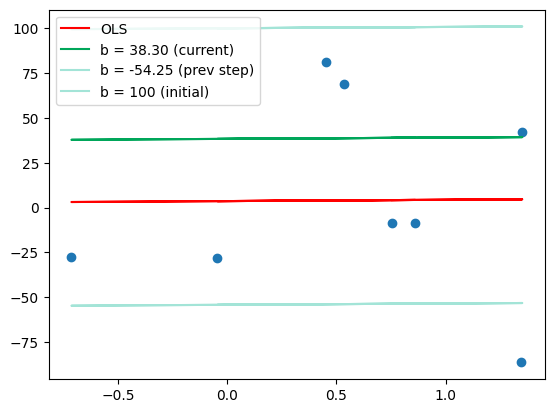

In [47]:
y_pred2 = ((0.73*X + b)).reshape(-1)
plt.scatter(X,y)
plt.plot(X,df.predict(X),color='red',label='OLS')
plt.plot(X,y_pred2,color='#00a65a',label='b = {:.2f} (current)'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = -54.25 (prev step)') # Approximated b from previous step
plt.plot(X,y_pred,color='#A3E4D7',label='b = 100 (initial)')
plt.legend()
plt.show()

In [48]:
#iteration3
loss_slope = -2 * np.sum(y- m*X.ravel()-b)
loss_slope

np.float64(555.2951677031797)

In [49]:
step_size = loss_slope * lr
step_size

np.float64(55.52951677031797)

In [50]:
b = b - step_size
b

np.float64(-17.228979848449057)

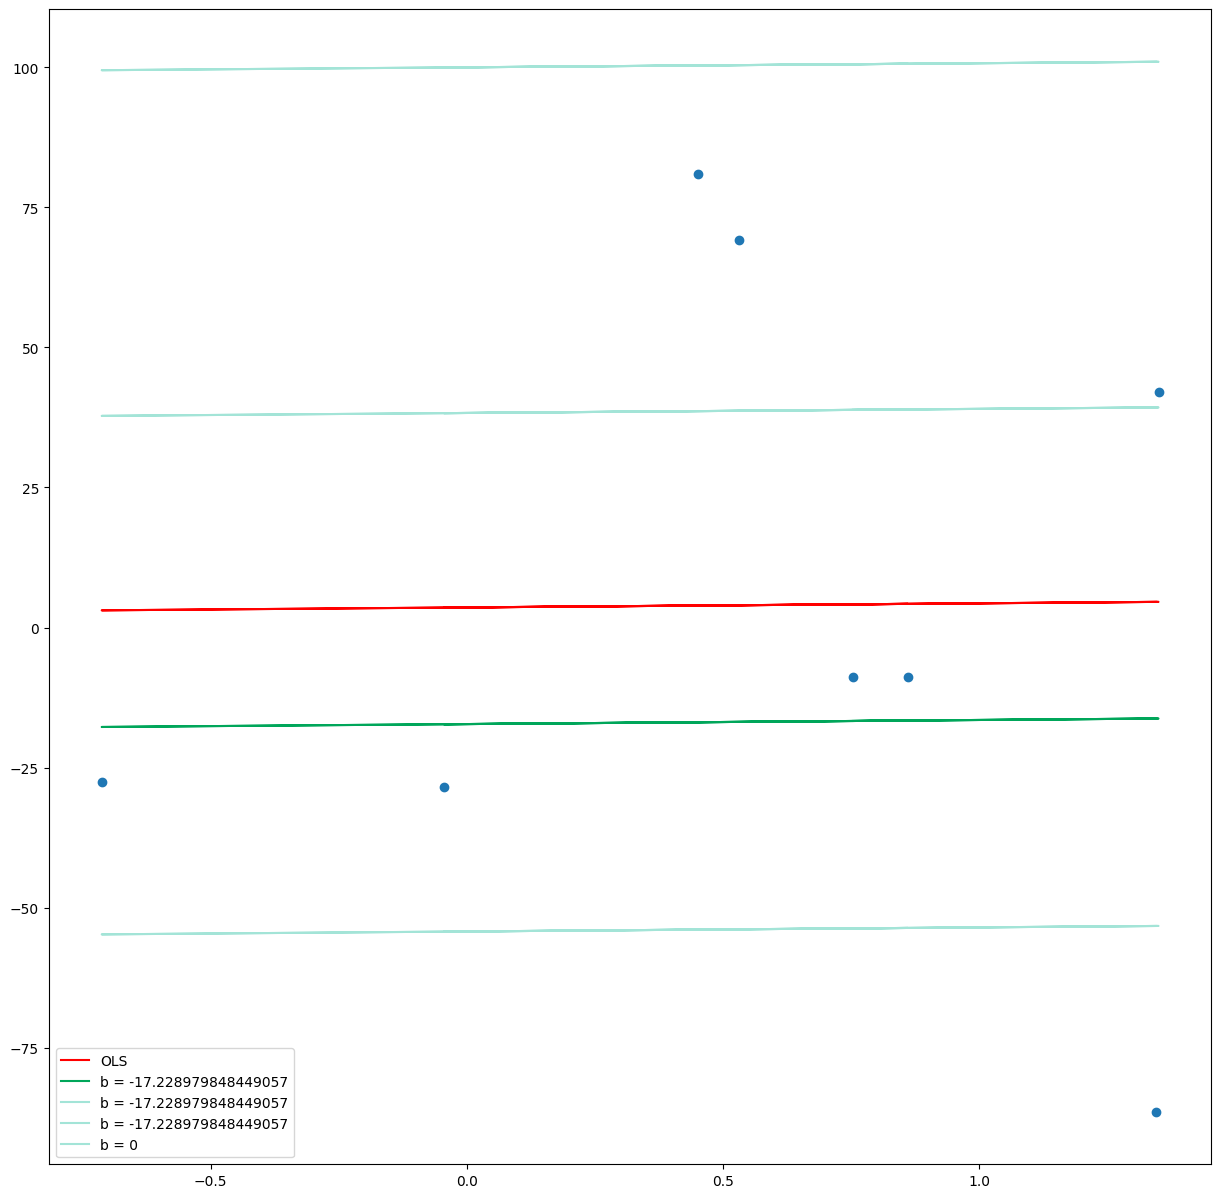

In [57]:

y_pred3 = ((0.73 * X) + b).reshape(-1)

plt.figure(figsize=(15,15))
plt.scatter(X,y)
plt.plot(X,df.predict(X),color='red',label='OLS')
plt.plot(X,y_pred3,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred2,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

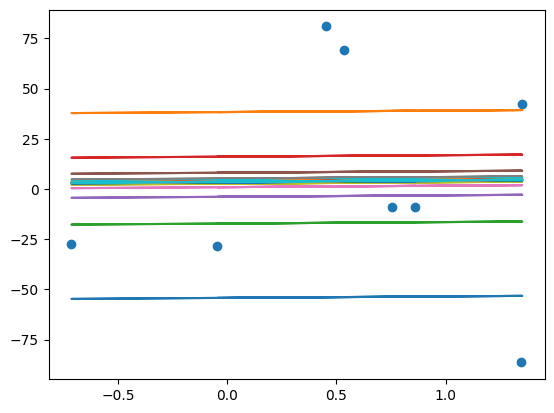

In [61]:
b = 100
m = 0.73
lr = 0.1

epochs = 20

for i in range(epochs):
  loss_slope = -2 * np.sum(y - m*X.ravel() - b)
  b = b - (lr * loss_slope)

  y_pred = m * X + b

  plt.plot(X,y_pred)

plt.scatter(X,y)